## Management Context and Evidence Base

This analysis examines passenger reviews to help airline management understand the main customer experience patterns and identify areas that may require attention. Using Student ID 36038040, a personalised sample of 600 reviews was generated from the provided dataset. The assigned service area is Seat Comfort. All analysis in this notebook uses the personalised `df_sub` sample.

The sample contains information about overall ratings, recommendation decisions, travel classes and five service areas. These data can be used to identify patterns and associations within the review sample. However, they do not represent every airline passenger and cannot prove that one service area directly causes a passenger to recommend or not recommend an airline.

### Running this notebook

Place `ETM1005_A2_AirlineReviews.csv` in the current working folder. In Google Colab, the next cell opens a file picker if the file is missing. Select **Run all**, upload the supplied CSV if prompted, and enter Student ID **36038040**. The supplied personalisation code below is unchanged.

In [1]:
from pathlib import Path

data_file = Path("ETM1005_A2_AirlineReviews.csv")
if not data_file.is_file():
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(
            "Place ETM1005_A2_AirlineReviews.csv in the current working folder."
        ) from None
    print("Please upload ETM1005_A2_AirlineReviews.csv.")
    files.upload()
    if not data_file.is_file():
        raise FileNotFoundError("The required CSV was not uploaded with its original filename.")


In [2]:
import pandas as pd

df = pd.read_csv("ETM1005_A2_AirlineReviews.csv")

sid_text = input("Enter your 8-digit Student ID: ").strip()
if not sid_text.isdigit() or len(sid_text) != 8:
    raise ValueError("Please enter your 8-digit Student ID.")

sid = int(sid_text)

# Create a stable record identifier before sampling
df = df.reset_index(drop=True).copy()
df["Record_ID"] = df.index + 1

# Personalised sample
df_sub = df.sample(n=600, random_state=sid).copy().reset_index(drop=True)

# Assigned service area
service_dimensions = [
    "Seat Comfort", "Staff Service", "Food & Beverages",
    "Inflight Entertainment", "Value For Money"
]
assigned_service = service_dimensions[sid % len(service_dimensions)]

In [3]:
print("Student ID:", sid_text)
print("Assigned service:", assigned_service)
print("Sample size:", len(df_sub))
print("Number of columns:", df_sub.shape[1])
print("Unique Record IDs:", df_sub["Record_ID"].nunique())

display(df_sub[["Record_ID", "Airline", "Class", "Seat Comfort", "Overall Rating", "Recommended"]].head())

Student ID: 36038040
Assigned service: Seat Comfort
Sample size: 600
Number of columns: 18
Unique Record IDs: 600


,Record_ID,Airline,Class,Seat Comfort,Overall Rating,Recommended
0,6620,Air France,Economy Class,1,4,no
1,1938,Qatar Airways,Economy Class,5,10,yes
2,4737,Turkish Airlines,Economy Class,3,1,no
3,3578,Emirates,Economy Class,1,1,no
4,3427,Emirates,Economy Class,5,5,no


In [4]:
# 1. Check column data types and missing values
quality_check = pd.DataFrame({
    "Data type": df_sub.dtypes.astype(str),
    "Missing values": df_sub.isna().sum()
})

display(quality_check)

# 2. Check summary statistics for the rating columns
rating_columns = [
    "Seat Comfort",
    "Staff Service",
    "Food & Beverages",
    "Inflight Entertainment",
    "Value For Money",
    "Overall Rating"
]

display(df_sub[rating_columns].describe().round(2))

# 3. check the categorical variables and their values in the sample
for column in ["Recommended", "Class", "Type of Traveller", "Airline"]:
    print(f"\n{column}")
    print(df_sub[column].value_counts(dropna=False))

,Data type,Missing values
Title,object,0
Name,object,0
Review Date,object,0
Airline,object,0
Verified,object,0
Reviews,object,0
Type of Traveller,object,0
Month Flown,object,0
Route,object,0
Class,object,0


,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating
count,600.00,600.00,600.00,600.00,600.00,600.00
mean,3.46,3.54,3.46,3.73,3.26,5.90
std,1.40,1.54,1.44,1.22,1.57,3.49
min,1.00,1.00,1.00,1.00,1.00,1.00
25%,2.00,2.00,2.00,3.00,2.00,2.00
50%,4.00,4.00,4.00,4.00,4.00,7.00
75%,5.00,5.00,5.00,5.00,5.00,9.00
max,5.00,5.00,5.00,5.00,5.00,10.00



Recommended
Recommended
yes    339
no     261
Name: count, dtype: int64

Class
Class
Economy Class      424
Business Class     143
Premium Economy     25
First Class          8
Name: count, dtype: int64

Type of Traveller
Type of Traveller
Solo Leisure      244
Couple Leisure    135
Family Leisure    121
Business          100
Name: count, dtype: int64

Airline
Airline
Qatar Airways             132
Turkish Airlines          124
Emirates                   87
Singapore Airlines         75
Air France                 55
Cathay Pacific Airways     45
All Nippon Airways         25
EVA Air                    23
Japan Airlines             19
Korean Air                 15
Name: count, dtype: int64


## Data Preparation

The personalised sample contains 600 reviews and 600 unique Record IDs. No missing values were found in the variables used in this analysis. The five service ratings range from 1 to 5, while the overall rating ranges from 1 to 10. Therefore, the overall rating is analysed separately rather than directly compared with the service rating means. No records were removed or replaced.

## Passenger Experience Diagnosis

,Value
Number of reviews,600.0
Mean overall rating,5.9
Median overall rating,7.0
Recommendation rate (%),56.5


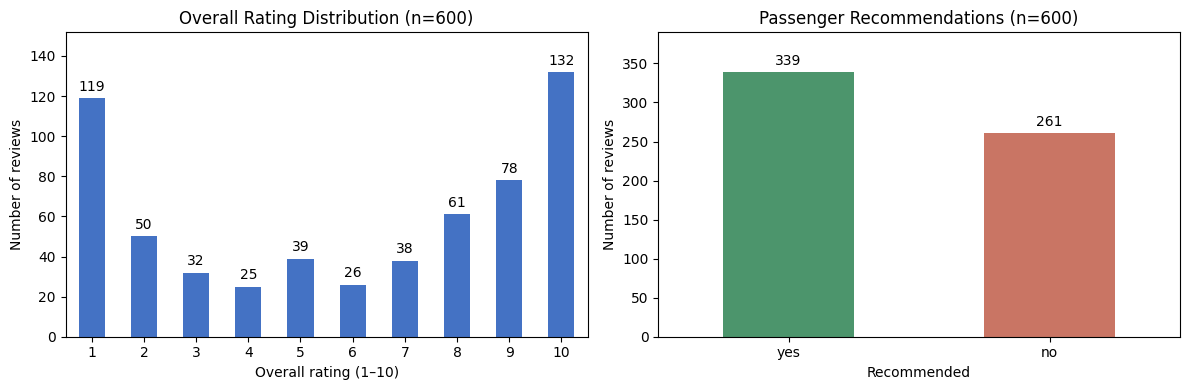

In [5]:
import matplotlib.pyplot as plt

# 1. calculate the overall experience summary statistics
experience_summary = pd.Series({
    "Number of reviews": len(df_sub),
    "Mean overall rating": df_sub["Overall Rating"].mean(),
    "Median overall rating": df_sub["Overall Rating"].median(),
    "Recommendation rate (%)": (
        df_sub["Recommended"].eq("yes").mean() * 100
    )
})

display(experience_summary.round(2).to_frame("Value"))

# 2. Count overall ratings and recommendation responses
overall_counts = (
    df_sub["Overall Rating"]
    .value_counts()
    .reindex(range(1, 11), fill_value=0)
)

recommendation_counts = (
    df_sub["Recommended"]
    .value_counts()
    .reindex(["yes", "no"], fill_value=0)
)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

overall_counts.plot.bar(ax=axes[0], color="#4472C4", rot=0)
axes[0].set_title(f"Overall Rating Distribution (n={len(df_sub)})")
axes[0].set_xlabel("Overall rating (1–10)")
axes[0].set_ylabel("Number of reviews")
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].margins(y=0.15)

recommendation_counts.plot.bar(
    ax=axes[1], color=["#4C956C", "#C97564"], rot=0
)
axes[1].set_title(f"Passenger Recommendations (n={len(df_sub)})")
axes[1].set_xlabel("Recommended")
axes[1].set_ylabel("Number of reviews")
axes[1].bar_label(axes[1].containers[0], padding=3)
axes[1].margins(y=0.15)

plt.tight_layout()
plt.show()

Overall ratings are concentrated at both ends of the scale, with 119 reviews giving a rating of 1 and 132 giving a rating of 10. Together, these account for 41.8% of the sample. The mean rating of 5.90 does not fully reflect this divided passenger experience. Furthermore, 261 out of 600 reviews (43.5%) do not recommend the airline, suggesting that negative experiences deserve management attention. Further analysis will examine seat comfort and whether its ratings are associated with passengers' willingness to recommend the airline.

## Seat Comfort Performance Assessment

,Number of reviews,Percentage (%)
Seat Comfort rating,,
1,89,14.83
2,64,10.67
3,114,19.00
4,148,24.67
5,185,30.83


,Valid reviews,Mean,Median,Low ratings (1–2) (%),High ratings (4–5) (%)
Seat Comfort,600,3.46,4.0,25.50,55.50
Staff Service,600,3.54,4.0,29.17,58.83
Food & Beverages,600,3.46,4.0,27.50,55.67
Inflight Entertainment,600,3.73,4.0,16.33,62.50
Value For Money,600,3.26,4.0,34.33,50.67


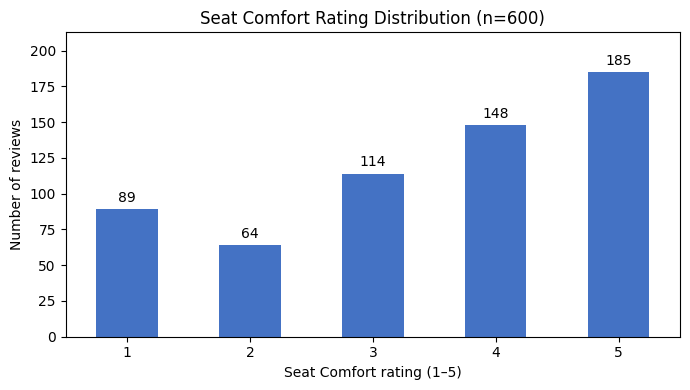

In [6]:
# 1. Count seat comfort ratings
seat_counts = (
    df_sub[assigned_service]
    .value_counts()
    .reindex(range(1, 6), fill_value=0)
)

seat_distribution = pd.DataFrame({
    "Number of reviews": seat_counts,
    "Percentage (%)": seat_counts / seat_counts.sum() * 100
})
seat_distribution.index.name = "Seat Comfort rating"

display(seat_distribution.round(2))

# 2. Compare the five service areas
# Define ratings 1-2 as low and ratings 4-5 as high
service_summary = pd.DataFrame({
    "Valid reviews": df_sub[service_dimensions].count(),
    "Mean": df_sub[service_dimensions].mean(),
    "Median": df_sub[service_dimensions].median(),
    "Low ratings (1–2) (%)": (
        df_sub[service_dimensions].isin([1, 2]).sum()
        / df_sub[service_dimensions].count() * 100
    ),
    "High ratings (4–5) (%)": (
        df_sub[service_dimensions].isin([4, 5]).sum()
        / df_sub[service_dimensions].count() * 100
    )
})

display(service_summary.round(2))

# 3. Plot the seat comfort rating distribution
ax = seat_counts.plot.bar(
    figsize=(7, 4),
    color="#4472C4",
    rot=0
)

ax.set_title(f"Seat Comfort Rating Distribution (n={seat_counts.sum()})")
ax.set_xlabel("Seat Comfort rating (1–5)")
ax.set_ylabel("Number of reviews")
ax.bar_label(ax.containers[0], padding=3)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

Most seat comfort ratings are positive, but low ratings should not be ignored. In this analysis, ratings of 1-2 are classified as low and ratings of 4-5 as high. The next step is to examine whether seat comfort ratings are associated with passengers' willingness to recommend the airline.

## Seat Comfort and Passenger Recommendation

,Recommended,Not recommended,Number of reviews,Recommendation rate (%)
Seat Comfort rating,,,,
1,41,48,89,46.07
2,35,29,64,54.69
3,53,61,114,46.49
4,89,59,148,60.14
5,121,64,185,65.41


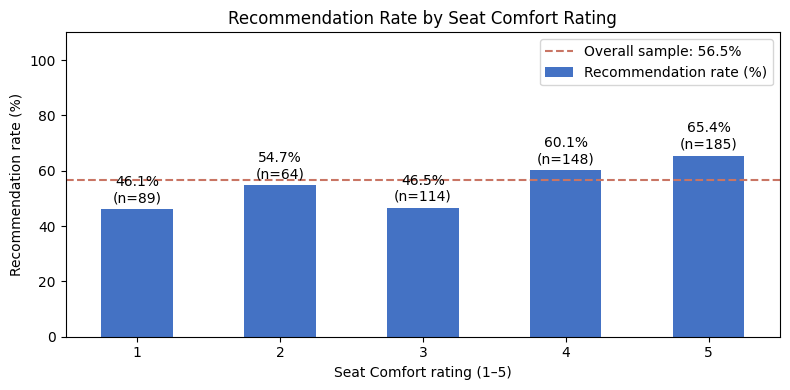

In [7]:
# 1. Count recommendations within each seat comfort rating
seat_recommendation = pd.crosstab(
    df_sub[assigned_service],
    df_sub["Recommended"]
).reindex(
    index=range(1, 6),
    columns=["yes", "no"],
    fill_value=0
)

seat_recommendation.columns = ["Recommended", "Not recommended"]
seat_recommendation.index.name = "Seat Comfort rating"

# 2. Calculate the recommendation rate within each rating group
seat_recommendation["Number of reviews"] = (
    seat_recommendation["Recommended"]
    + seat_recommendation["Not recommended"]
)

seat_recommendation["Recommendation rate (%)"] = (
    seat_recommendation["Recommended"]
    / seat_recommendation["Number of reviews"] * 100
)

display(seat_recommendation.round(2))

# 3. Plot recommendation rates by rating
ax = seat_recommendation["Recommendation rate (%)"].plot.bar(
    figsize=(8, 4),
    color="#4472C4",
    rot=0
)

ax.set_title("Recommendation Rate by Seat Comfort Rating")
ax.set_xlabel("Seat Comfort rating (1–5)")
ax.set_ylabel("Recommendation rate (%)")
ax.set_ylim(0, 110)
ax.set_yticks(range(0, 101, 20))

# Label each bar with its recommendation rate and sample size
labels = [
    f"{rate:.1f}%\n(n={n})"
    for rate, n in zip(
        seat_recommendation["Recommendation rate (%)"],
        seat_recommendation["Number of reviews"]
    )
]

ax.bar_label(ax.containers[0], labels=labels, padding=3)

# The dashed line shows the recommendation rate for the full sample
overall_recommendation_rate = (
    df_sub["Recommended"].eq("yes").mean() * 100
)

ax.axhline(
    overall_recommendation_rate,
    color="#C97564",
    linestyle="--",
    label=f"Overall sample: {overall_recommendation_rate:.1f}%"
)

ax.legend()
plt.tight_layout()
plt.show()

Recommendation rates generally increase with seat comfort ratings. The rate rises from 46.1% for rating 1 to 65.4% for rating 5, while ratings 4 and 5 are both above the overall sample rate of 56.5%. However, rating 3 is an exception, with a recommendation rate of 46.5%, lower than the 54.7% for rating 2. This irregularity means that the relationship is positive overall but not perfectly consistent. The result suggests an association between seat comfort and recommendation, but it does not establish that seat comfort directly causes passengers to recommend the airline.

## Further Investigation by Travel Class

In [8]:
# Summarise seat comfort and recommendation rates by travel class
class_seat_summary = (
    df_sub
    .groupby("Class")
    .agg(
        Number_of_reviews=("Record_ID", "size"),
        Mean_seat_comfort=("Seat Comfort", "mean"),
        Recommendation_rate=(
            "Recommended",
            lambda x: x.eq("yes").mean() * 100
        )
    )
    .sort_values("Number_of_reviews", ascending=False)
)

display(class_seat_summary.round(2))

,Number_of_reviews,Mean_seat_comfort,Recommendation_rate
Class,,,
Economy Class,424,3.44,52.83
Business Class,143,3.41,66.43
Premium Economy,25,3.72,52.00
First Class,8,4.38,87.50


In [9]:
# Calculate the percentage in each seat rating band within each class
class_seat_distribution = pd.crosstab(
    df_sub["Class"],
    pd.cut(
        df_sub["Seat Comfort"],
        bins=[0, 2, 3, 5],
        labels=["Low (1-2)", "Medium (3)", "High (4-5)"]
    ),
    normalize="index"
) * 100

display(class_seat_distribution.round(2))

Seat Comfort,Low (1-2),Medium (3),High (4-5)
Class,,,
Business Class,28.67,17.48,53.85
Economy Class,25.24,19.58,55.19
First Class,0.00,25.00,75.00
Premium Economy,20.00,16.00,64.00


In [10]:
# Calculate sample sizes and recommendation rates by class and seat rating
class_rating_check = (
    df_sub
    .groupby(["Class", "Seat Comfort"])
    .agg(
        Number_of_reviews=("Record_ID", "size"),
        Recommended_count=(
            "Recommended",
            lambda x: x.eq("yes").sum()
        )
    )
)

class_rating_check["Recommendation_rate_pct"] = (
    class_rating_check["Recommended_count"]
    / class_rating_check["Number_of_reviews"] * 100
)

# Focus on the rating 2 and rating 3 groups
comparison_2_3 = class_rating_check.loc[
    class_rating_check.index.get_level_values("Seat Comfort").isin([2, 3])
]

display(comparison_2_3.round(2))

Number_of_reviews  Recommended_count  \
Class           Seat Comfort                                         
Business Class  2                            14                  9   
                3                            25                 13   
Economy Class   2                            47                 25   
                3                            83                 37   
First Class     3                             2                  2   
Premium Economy 2                             3                  1   
                3                             4                  1   

                              Recommendation_rate_pct  
Class           Seat Comfort                           
Business Class  2                               64.29  
                3                               52.00  
Economy Class   2                               53.19  
                3                               44.58  
First Class     3                              100.00  
Premium Economy 2                               33.33  
                3                               25.00

## Other Service Ratings Within Seat Comfort Groups

In [11]:
# Select Economy and Business Class reviews with seat ratings of 2 or 3
# All records come from the personalised df_sub sample
comparison_sample = df_sub[
    df_sub["Class"].isin(["Economy Class", "Business Class"])
    & df_sub["Seat Comfort"].isin([2, 3])
]

# Compare other service ratings and overall experience within each class
other_service_check = (
    comparison_sample
    .groupby(["Class", "Seat Comfort"])
    .agg(
        Number_of_reviews=("Record_ID", "size"),
        Mean_staff_service=("Staff Service", "mean"),
        Mean_food=("Food & Beverages", "mean"),
        Mean_entertainment=("Inflight Entertainment", "mean"),
        Mean_value_for_money=("Value For Money", "mean"),
        Mean_overall_rating=("Overall Rating", "mean"),
        Recommendation_rate_pct=(
            "Recommended",
            lambda x: x.eq("yes").mean() * 100
        )
    )
)

# Transpose the table to display the four groups side by side
display(other_service_check.round(2).T)

Class                   Business Class        Economy Class       
Seat Comfort                         2      3             2      3
Number_of_reviews                14.00  25.00         47.00  83.00
Mean_staff_service                3.21   3.48          3.21   3.41
Mean_food                         2.93   3.32          3.17   3.45
Mean_entertainment                3.50   3.48          3.62   3.87
Mean_value_for_money              3.79   3.16          3.04   2.87
Mean_overall_rating               6.79   6.44          5.17   4.95
Recommendation_rate_pct          64.29  52.00         53.19  44.58

In both Economy Class and Business Class, passengers who rated seat comfort 3 had a lower recommendation rate than those who rated it 2. The rating 3 group also had lower value-for-money and overall ratings in both classes, which may help explain the lower recommendation rates. However, their staff service and food ratings were higher, so the result does not show that every part of their experience was worse. This comparison only shows an association between the ratings, and it cannot explain the exact reason for the difference. The Business Class groups were also relatively small, with 14 and 25 reviews, so the results should be interpreted carefully.

## Management Implications and Limitations

The results show that seat comfort is generally rated positively, with a mean of 3.46 out of 5 and 55.5% of reviews giving a rating of 4 or 5. However, 25.5% of reviews gave a low rating of 1 or 2, so there is still a group of passengers whose seat experience requires management attention.

Passengers with seat comfort ratings of 4 and 5 had recommendation rates above the overall sample rate. This suggests that seat comfort is related to passengers’ recommendation decisions. However, the pattern was not completely consistent because the rating 3 group had a lower recommendation rate than the rating 2 group.

Further analysis showed that this irregular pattern also appeared within Economy Class and Business Class. In both classes, the rating 3 group had lower value-for-money ratings, overall ratings and recommendation rates than the rating 2 group. Management should therefore examine seat comfort together with value for money and the wider passenger experience, rather than treating seat comfort as the only issue.

These findings are based on a personalised sample of 600 reviews and show associations rather than causation. Some groups were also small, especially First Class with only eight reviews and the Business Class comparison groups with 14 and 25 reviews. Results from these smaller groups should be interpreted carefully.

## Results Fingerprint

In [12]:
# Results Fingerprint: key personalisation details and computed evidence
results_fingerprint = pd.DataFrame({
    "Metric": [
        "Student ID",
        "Assigned service area",
        "Personalised sample size",
        "Unique Record IDs",
        "Record ID checksum",
        "Mean overall rating (1-10)",
        "Median overall rating (1-10)",
        "Recommendation rate (%)",
        "Mean seat comfort rating (1-5)",
        "Low seat comfort ratings, 1-2 (%)",
        "High seat comfort ratings, 4-5 (%)",
        "Recommendation rate at seat rating 1 (%)",
        "Recommendation rate at seat rating 2 (%)",
        "Recommendation rate at seat rating 3 (%)",
        "Recommendation rate at seat rating 5 (%)"
    ],
    "Value": [
        sid_text,
        assigned_service,
        len(df_sub),
        df_sub["Record_ID"].nunique(),
        df_sub["Record_ID"].sum(),
        round(df_sub["Overall Rating"].mean(), 2),
        round(df_sub["Overall Rating"].median(), 2),
        round(df_sub["Recommended"].eq("yes").mean() * 100, 2),
        round(df_sub["Seat Comfort"].mean(), 2),
        round(df_sub["Seat Comfort"].isin([1, 2]).mean() * 100, 2),
        round(df_sub["Seat Comfort"].isin([4, 5]).mean() * 100, 2),
        round(seat_recommendation.loc[1, "Recommendation rate (%)"], 2),
        round(seat_recommendation.loc[2, "Recommendation rate (%)"], 2),
        round(seat_recommendation.loc[3, "Recommendation rate (%)"], 2),
        round(seat_recommendation.loc[5, "Recommendation rate (%)"], 2)
    ]
})

display(results_fingerprint)

# Key subgroup evidence supporting the investigation of ratings 2 and 3
fingerprint_groups = other_service_check[[
    "Number_of_reviews", "Mean_value_for_money",
    "Mean_overall_rating", "Recommendation_rate_pct"
]].rename(columns={
    "Number_of_reviews": "Reviews",
    "Mean_value_for_money": "Mean value for money (1-5)",
    "Mean_overall_rating": "Mean overall rating (1-10)",
    "Recommendation_rate_pct": "Recommendation rate (%)"
})
display(fingerprint_groups.round(2))


,Metric,Value
0,Student ID,36038040
1,Assigned service area,Seat Comfort
2,Personalised sample size,600
3,Unique Record IDs,600
4,Record ID checksum,2371990
5,Mean overall rating (1-10),5.9
6,Median overall rating (1-10),7.0
7,Recommendation rate (%),56.5
8,Mean seat comfort rating (1-5),3.46
9,"Low seat comfort ratings, 1-2 (%)",25.5


Reviews  Mean value for money (1-5)  \
Class          Seat Comfort                                        
Business Class 2                  14                        3.79   
               3                  25                        3.16   
Economy Class  2                  47                        3.04   
               3                  83                        2.87   

                             Mean overall rating (1-10)  \
Class          Seat Comfort                               
Business Class 2                                   6.79   
               3                                   6.44   
Economy Class  2                                   5.17   
               3                                   4.95   

                             Recommendation rate (%)  
Class          Seat Comfort                           
Business Class 2                               64.29  
               3                               52.00  
Economy Class  2                               53.19  
               3                               44.58